# Low Volatility Anomaly

Low-volatility stocks have historically delivered higher risk-adjusted returns than the CAPM predicts. We rank stocks by their trailing realized volatility and go long the lowest, short the highest. The standard explanations are leverage constraints among institutional investors and lottery-preference behaviour among retail investors, both of which bid up high-vol stocks past their fair value.


## Updated methodology

Numbers in this notebook differ from earlier versions: point-in-time membership masking, an `exec_lag=2` execution model, and Deflated Sharpe reporting are now applied. Previous in-sample optimised Sharpe: **-0.874**.

**Significance verdict (5 bps cost, HAC SE):** Optimized in-sample alpha is -8.27% (t = -1.91), out-of-sample is +2.56% (t = 0.34). **This strategy does not pass |t| > 2 in any configuration tested.**


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from signals import low_volatility
from helper import (
    ic, quick_weights, port_ret, stats, Optimizer,
    dist_plot, var_cvar, neutralize, beta_to,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


## Data

Adjusted close prices for current S&P 500 constituents from 2005 onward. The dataset uses today's index members, so it is subject to survivorship bias: stocks that were delisted or removed are not represented. This is acknowledged in the README; correcting it requires a point-in-time constituent history that is not freely available.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change()
IS_END = '2020-12-31'
close.shape, close.index[[0, -1]]
members = pd.read_parquet('../data/members.parquet')


In [3]:
coverage = close.notna().sum(axis=1)
print(f'Tickers: {close.shape[1]}, Trading days: {close.shape[0]}')
print(f'Avg coverage: {coverage.mean():.0f}, Min: {coverage.min()}, Max: {coverage.max()}')


Tickers: 832, Trading days: 5344
Avg coverage: 566, Min: 472, Max: 635


## Signal Construction

The signal is defined in `signals.py` and imported here so the notebook focuses on evaluation. We compute on the full panel and slice for in-sample versus out-of-sample analysis.


In [4]:
signal = low_volatility(close, lookback=63)
signal.stack().describe()


count   2967761.0000
mean         -0.0208
std           0.0143
min          -0.3137
25%          -0.0239
50%          -0.0170
75%          -0.0127
max          -0.0000
dtype: float64

Distribution of raw signal values across all stocks and dates. Heavy tails or asymmetry here propagate into the portfolio, which is why the optimizer rank-normalises before solving.


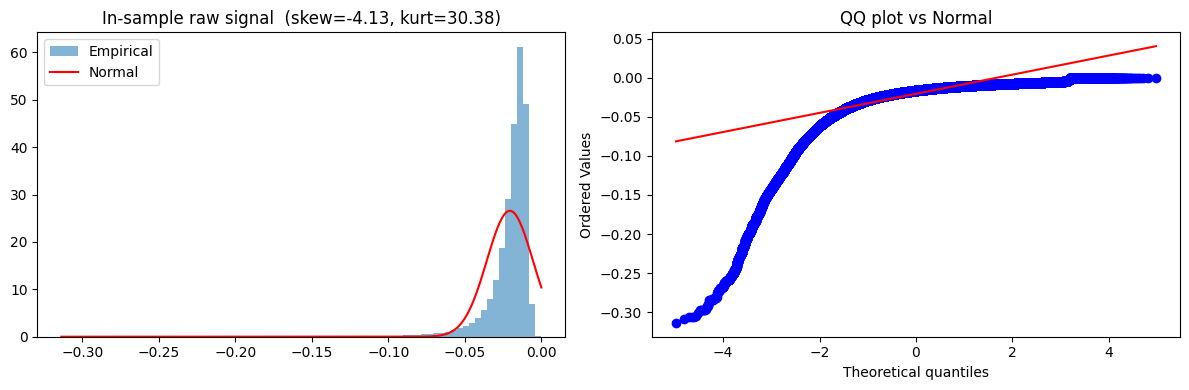

In [5]:
dist_plot(signal.loc[:IS_END].stack(), title='In-sample raw signal')


## Information Coefficient

Spearman rank correlation between today's signal and forward returns at multiple horizons. ICIR scales the mean IC by its time-series standard deviation; values around 0.05 in IC and 0.5 in ICIR are the conventional bar for a daily cross-sectional signal.


In [6]:
ic_is = ic(signal.loc[:IS_END], close.loc[:IS_END])
ic_is


,IC,ICIR
1,0.0087,0.0369
5,-0.0009,-0.0039
10,-0.0067,-0.0296
20,-0.0141,-0.0629


## Parameter Grid: IC Heatmap

Two-dimensional grid over (`lookback`, forward horizon). Each cell is the mean IC of the signal at that parameter and horizon. A signal whose performance is highly sensitive to a single point in the grid is more likely to be a fitting artefact than a real effect.


In [7]:
grid = [21, 63, 126, 252]
ic_results = {}
for p in grid:
    sig = low_volatility(close, lookback=p)
    ic_results[p] = ic(sig.loc[:IS_END], close.loc[:IS_END])
ic_all = pd.concat(ic_results, names=['lookback'])
ic_all


IC    ICIR
lookback                   
21       1   0.0085  0.0388
         5  -0.0001 -0.0007
         10 -0.0043 -0.0205
         20 -0.0098 -0.0473
63       1   0.0087  0.0369
         5  -0.0009 -0.0039
         10 -0.0067 -0.0296
         20 -0.0141 -0.0629
126      1   0.0081  0.0338
         5  -0.0016 -0.0069
         10 -0.0074 -0.0316
         20 -0.0146 -0.0627
252      1   0.0074  0.0303
         5  -0.0022 -0.0091
         10 -0.0075 -0.0313
         20 -0.0144 -0.0605

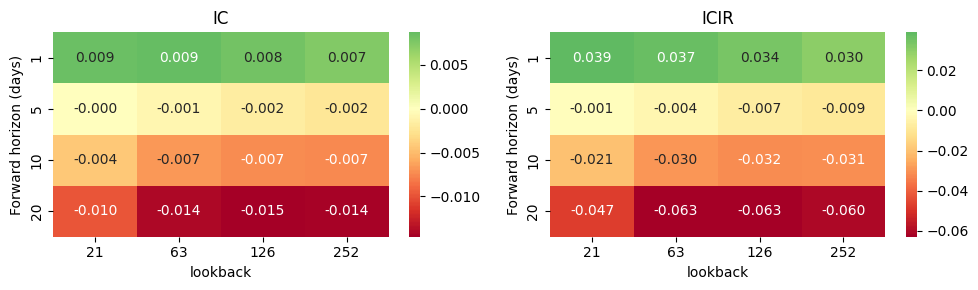

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i, col in enumerate(['IC', 'ICIR']):
    pivot = ic_all[col].unstack(level=0)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Forward horizon (days)')
    axes[i].set_xlabel('lookback')
plt.tight_layout()
plt.show()


## Rolling IC Stability

A signal that worked once and decayed is not the same as one that works persistently. The rolling 1-year IC tells us whether the predictive content survives across regimes.


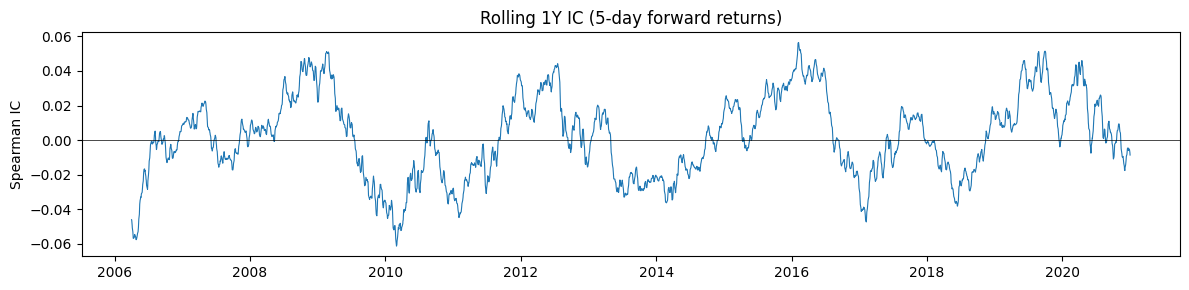

% of days with positive IC: 47.7%


In [9]:
fwd_5d = close.pct_change(5).shift(-5)
daily_ic = signal.loc[:IS_END].corrwith(fwd_5d.loc[:IS_END], axis=1, method='spearman')
rolling_ic = daily_ic.rolling(252).mean()
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rolling_ic, linewidth=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Rolling 1Y IC (5-day forward returns)')
ax.set_ylabel('Spearman IC')
plt.tight_layout()
plt.show()
print(f'% of days with positive IC: {(daily_ic > 0).mean():.1%}')


## In-Sample Backtest: Rank Weights

Dollar-neutral rank-weighted portfolio with no transaction costs. The cheapest possible expression of the signal, useful as a baseline before introducing the optimizer.


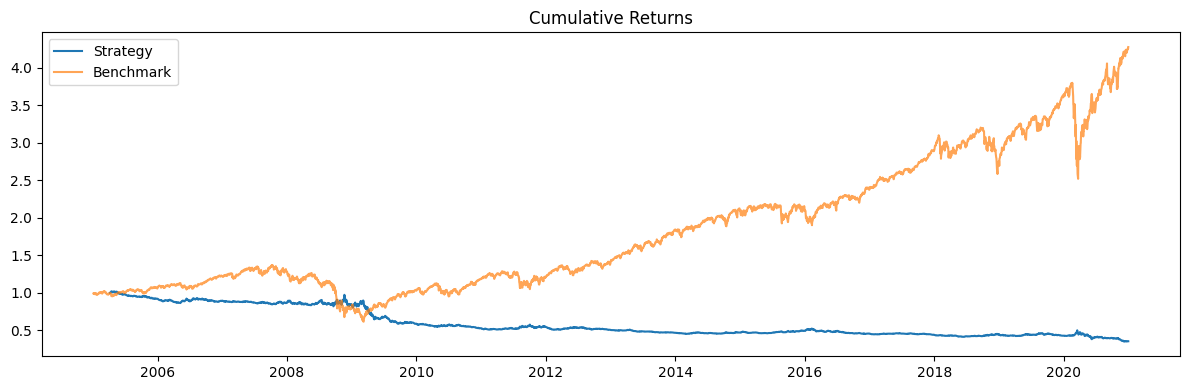

PSR (target 0):  0.005
DSR (n_trials=20): 0.000


In [10]:
is_signal = signal.loc[:IS_END]
is_returns = returns.loc[:IS_END]
w_quick = quick_weights(is_signal, dollar_neutral=True)
pnl_quick = port_ret(w_quick, is_returns)
stats_quick = stats(pnl_quick, weights=w_quick, benchmark=spy.loc[:IS_END])
stats_quick
from helper import deflated_sharpe, probabilistic_sharpe
print(f'PSR (target 0):  {probabilistic_sharpe(pnl_quick.dropna()):.3f}')
print(f'DSR (n_trials=20): {deflated_sharpe(pnl_quick.dropna(), n_trials=20):.3f}')


## Transaction Cost Sensitivity

Daily-rebalanced strategies are turnover-intensive. The Sharpe at non-zero costs is what matters in production.


In [11]:
tcost_grid = [0, 2, 5, 10, 20]
tcost_sharpes = {}
for tc in tcost_grid:
    pnl = port_ret(w_quick, is_returns, tcost_bps=tc)
    sr = pnl.mean() / pnl.std() * np.sqrt(252)
    tcost_sharpes[tc] = round(sr, 3)
pd.Series(tcost_sharpes, name='Sharpe').rename_axis('tcost (bps)')


tcost (bps)
0    -0.6470
2    -0.6680
5    -0.7000
10   -0.7530
20   -0.8600
Name: Sharpe, dtype: float64

## In-Sample Backtest: Optimized Weights

Mean-variance optimizer with a 5 bps transaction-cost penalty and a 2% per-name position cap. The optimizer trades signal strength against covariance risk and rebalancing cost, producing weights that are not achievable from a one-shot ranking.


  solved 200/806


  solved 400/806


  solved 600/806


  solved 800/806


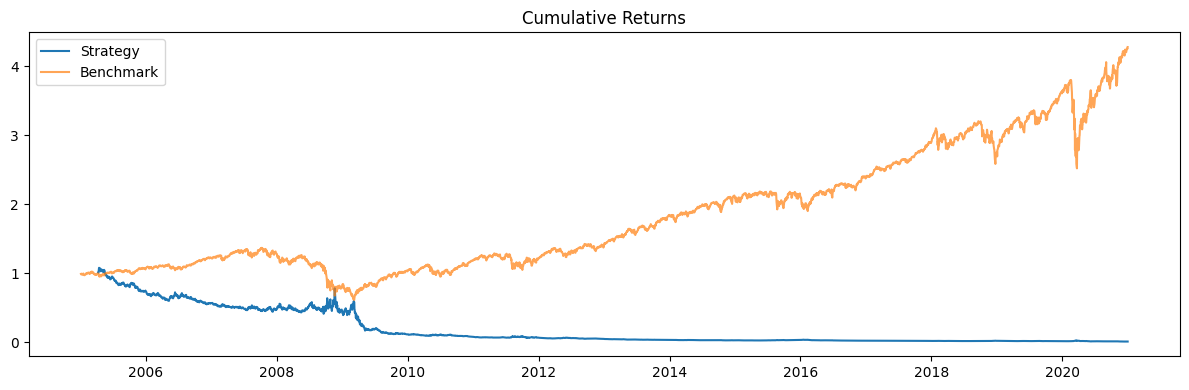

PSR (target 0):  0.003
DSR (n_trials=20): 0.000


In [12]:
opt = Optimizer(is_signal, is_returns)
w_opt = opt.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_opt = port_ret(w_opt, is_returns, tcost_bps=5)
stats_opt = stats(pnl_opt, weights=w_opt, benchmark=spy.loc[:IS_END])
stats_opt
from helper import deflated_sharpe, probabilistic_sharpe
print(f'PSR (target 0):  {probabilistic_sharpe(pnl_opt.dropna()):.3f}')
print(f'DSR (n_trials=20): {deflated_sharpe(pnl_opt.dropna(), n_trials=20):.3f}')


In [13]:
pd.concat([stats_quick.rename(index={'Strategy': 'Rank-weighted'}),
           stats_opt.rename(index={'Strategy': 'Optimized'})])


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Rank-weighted,-6.21%,9.60%,-0.6470,-2.5860,-65.93%,-42.37%,3956 days,-2.61%,-1.5310,-0.3200,4.00%
Optimized,-24.68%,36.17%,-0.6820,-2.7270,-99.34%,-82.91%,3956 days,-7.04%,-1.6320,-1.5620,3.37%


## Return Distribution and Tail Risk

Sharpe summarises the joint distribution but hides the tails. We plot the empirical return distribution against the Gaussian implied by the same mean and variance, then quantify tail risk via historical and parametric VaR / CVaR. The gap between the two estimates is itself informative: large gaps mean the Gaussian is a poor model for tail risk.


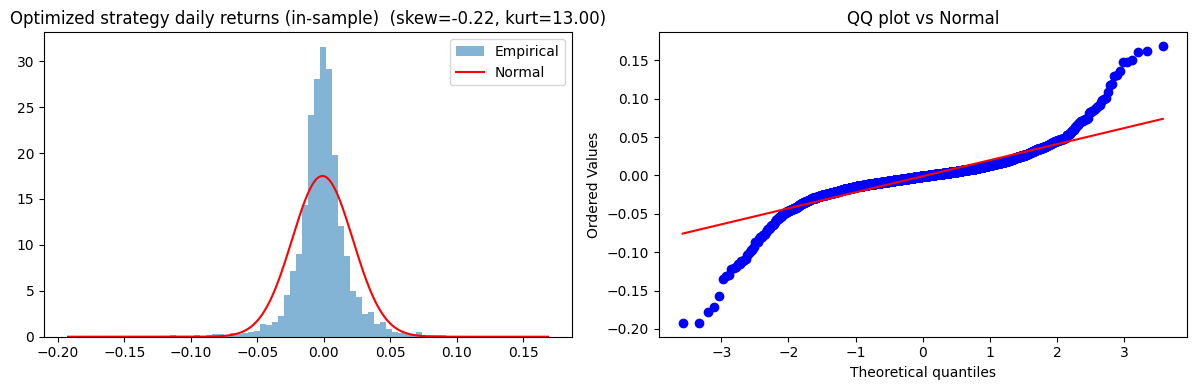

In [14]:
dist_plot(pnl_opt, title='Optimized strategy daily returns (in-sample)')


In [15]:
var_cvar(pnl_opt, alpha=0.05)


,VaR,CVaR
historical,-2.99%,-5.60%
parametric,-3.85%,-4.80%


In [16]:
var_cvar(pnl_opt, alpha=0.01)


,VaR,CVaR
historical,-7.14%,-10.73%
parametric,-5.40%,-6.17%


## Out-of-Sample Validation (2021 onward)

Everything above used data through end of 2020. The post-2020 panel is the genuine test: no parameter was chosen with reference to it.


In [17]:
oos_signal = signal.loc[IS_END:]
oos_returns = returns.loc[IS_END:]
ic(oos_signal, close.loc[IS_END:])


,IC,ICIR
1,0.0052,0.0189
5,-0.0008,-0.0029
10,-0.0015,-0.0059
20,0.0012,0.0049


  solved 200/264


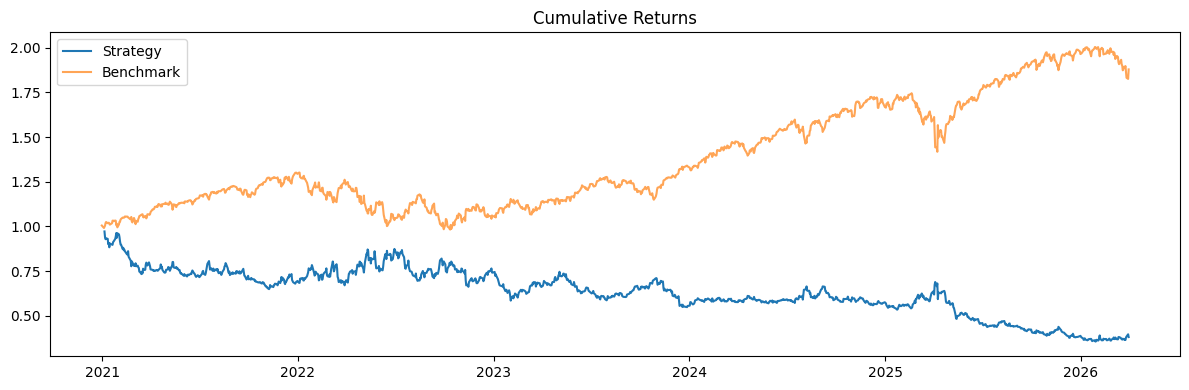

PSR (target 0):  0.117
DSR (n_trials=20): 0.000


In [18]:
opt_oos = Optimizer(oos_signal, oos_returns)
w_oos = opt_oos.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_oos = port_ret(w_oos, oos_returns, tcost_bps=5)
stats_oos = stats(pnl_oos, weights=w_oos, benchmark=spy.loc[IS_END:])
stats_oos
from helper import deflated_sharpe, probabilistic_sharpe
print(f'PSR (target 0):  {probabilistic_sharpe(pnl_oos.dropna()):.3f}')
print(f'DSR (n_trials=20): {deflated_sharpe(pnl_oos.dropna(), n_trials=20):.3f}')


In [19]:
pd.concat([stats_opt.rename(index={'Strategy': 'In-sample (2005-2020)'}),
           stats_oos.rename(index={'Strategy': 'Out-of-sample (2021+)'})])


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
In-sample (2005-2020),-24.68%,36.17%,-0.6820,-2.7270,-99.34%,-82.91%,3956 days,-7.04%,-1.6320,-1.5620,3.37%
Out-of-sample (2021+),-14.54%,27.94%,-0.5200,-1.1900,-63.33%,-34.63%,1314 days,2.56%,0.3370,-1.2490,7.12%


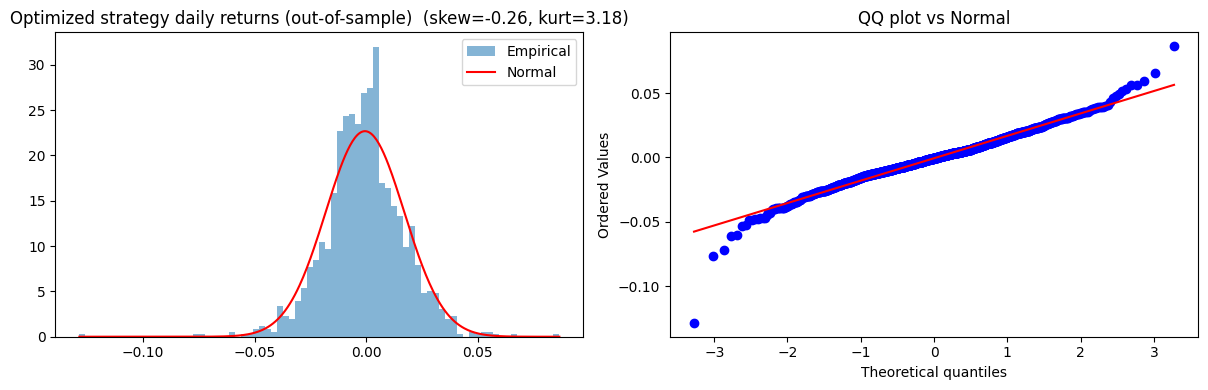

In [20]:
dist_plot(pnl_oos, title='Optimized strategy daily returns (out-of-sample)')


In [21]:
var_cvar(pnl_oos, alpha=0.05)


,VaR,CVaR
historical,-2.81%,-3.99%
parametric,-2.95%,-3.69%


## Annual Returns

Year-by-year breakdown highlights regime sensitivity that aggregate Sharpe figures hide.


In [22]:
full_signal = signal.loc['2006':]
full_returns = returns.loc['2006':]
w_full = quick_weights(full_signal, dollar_neutral=True)
pnl_full = port_ret(w_full, full_returns)
annual = pnl_full.groupby(pnl_full.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_spy = spy.loc['2006':].groupby(spy.loc['2006':].index.year).apply(lambda x: (1 + x).prod() - 1)
annual_df = pd.DataFrame({'Strategy': annual, 'SPY': annual_spy, 'Excess': annual - annual_spy})
annual_df.style.format('{:.2%}')


,Strategy,SPY,Excess
Date,,,
2006,-2.59%,15.85%,-18.43%
2007,-2.97%,5.15%,-8.12%
2008,-3.46%,-36.80%,33.33%
2009,-29.74%,26.35%,-56.09%
2010,-10.46%,15.06%,-25.52%
2011,4.11%,1.89%,2.21%
2012,-8.15%,15.99%,-24.14%
2013,-7.36%,32.31%,-39.67%
2014,0.40%,13.46%,-13.07%


## Save Weights

Persist optimised weights and signal panel so the portfolio capstone and the Monte Carlo notebook can consume them without recomputing.


In [23]:
w_opt.to_parquet('../data/weights_03_low_volatility_is.parquet')
w_oos.to_parquet('../data/weights_03_low_volatility_oos.parquet')
signal.to_parquet('../data/signal_03_low_volatility.parquet')
